<a href="https://colab.research.google.com/github/lsp-learning/cicids2017-ai-ml-project/blob/main/01_EDA/EDA_CICIDS2017.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

In [3]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount("/content/drive",force_remount=True)
#

Mounted at /content/drive


In [4]:
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, r2_score, classification_report

# to restrict the float value to 3 decimal places
pd.set_option('display.float_format', lambda x: '%.3f' % x)

df = pd.read_csv("/content/drive/MyDrive/Python/cicids2017_cleaned.csv")

df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.976,109.865,976,0,...,243,24,32,0.000,0,0,0.000,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.976,109.865,976,0,...,243,24,32,0.000,0,0,0.000,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000,0.000,0,0,...,243,0,32,0.000,0,0,0.000,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.537,110.130,976,0,...,243,24,32,0.000,0,0,0.000,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000,0.000,0,0,...,290,0,32,0.000,0,0,0.000,0,0,Normal Traffic


In [4]:

print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{list(df.columns)}")
print(f"\nLabel column unique values:\n{df['Attack Type'].value_counts()}")


Shape: (2520751, 53)

Column names:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Max', 'Activ

In [24]:
print("Shape:", df.shape)

Shape: (2520751, 53)


In [26]:
df['Attack Type'].value_counts()

,count
Attack Type,
Normal Traffic,2095057
DoS,193745
DDoS,128014
Port Scanning,90694
Brute Force,9150
Web Attacks,2143
Bots,1948


In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Check 1: Missing values
null_counts = df.isnull().sum()
print("=== Missing Values ===")
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "None found ✅")

# Check 2: Infinite values (known CICIDS2017 issue)
inf_counts = np.isinf(df[numeric_cols]).sum()
inf_cols = inf_counts[inf_counts > 0]
print("\n=== Infinite Values ===")
print(inf_cols if len(inf_cols) > 0 else "None found ✅")

# Check 3: Duplicates
print(f"\n=== Duplicate Rows ===")
print(f"{df.duplicated().sum():,} duplicates found")

=== Missing Values ===
None found ✅

=== Infinite Values ===
None found ✅

=== Duplicate Rows ===
161 duplicates found


In [6]:

# Dropping the duplicates

df.drop_duplicates(inplace=True)
print(f"Rows after dedup: {len(df):,}")


Rows after dedup: 2,520,590


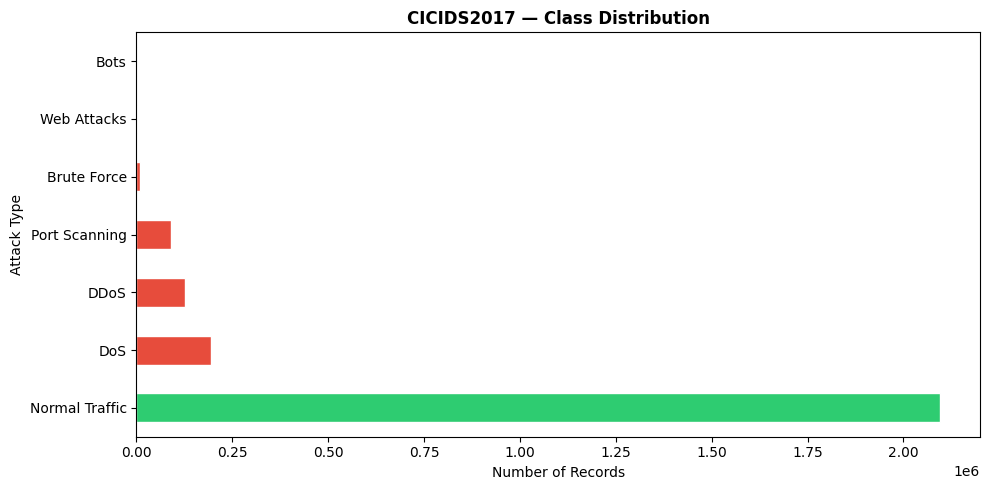

In [7]:
label_counts = df['Attack Type'].value_counts()

label_counts.plot(kind='barh',
                  color=['#2ecc71' if 'Normal' in l else '#e74c3c' for l in label_counts.index],
                  edgecolor='white',
                  figsize=(10, 5))

plt.title('CICIDS2017 — Class Distribution', fontweight='bold')
plt.xlabel('Number of Records')
plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
df['Traffic_Type'] = df['Attack Type'].apply(
    lambda x: 'Normal' if x == 'Normal Traffic' else 'Attack'
)

df['Traffic_Type'].value_counts()

,count
Traffic_Type,
Normal,2094896
Attack,425694


In [9]:
df.groupby('Traffic_Type')[['Flow Duration', 'Flow Packets/s',
                              'Flow Bytes/s', 'Init_Win_bytes_forward']].mean().round(2)

,Flow Duration,Flow Packets/s,Flow Bytes/s,Init_Win_bytes_forward
Traffic_Type,,,,
Attack,38392996.360,16460.680,106225.520,7175.000
Normal,12161172.980,53541.100,1675890.150,7283.420


In [10]:
df.groupby('Attack Type')[['Flow Duration', 'Flow Packets/s',
                             'Flow Bytes/s']].mean().round(2)

,Flow Duration,Flow Packets/s,Flow Bytes/s
Attack Type,,,
Bots,354185.440,43995.050,290128.740
Brute Force,7891160.130,5818.590,25015.560
DDoS,16957157.950,155.390,60509.890
DoS,72634739.580,1619.000,70554.570
Normal Traffic,12161172.980,53541.100,1675890.150
Port Scanning,145096.460,71995.390,253704.240
Web Attacks,6646525.880,2406.290,160.640


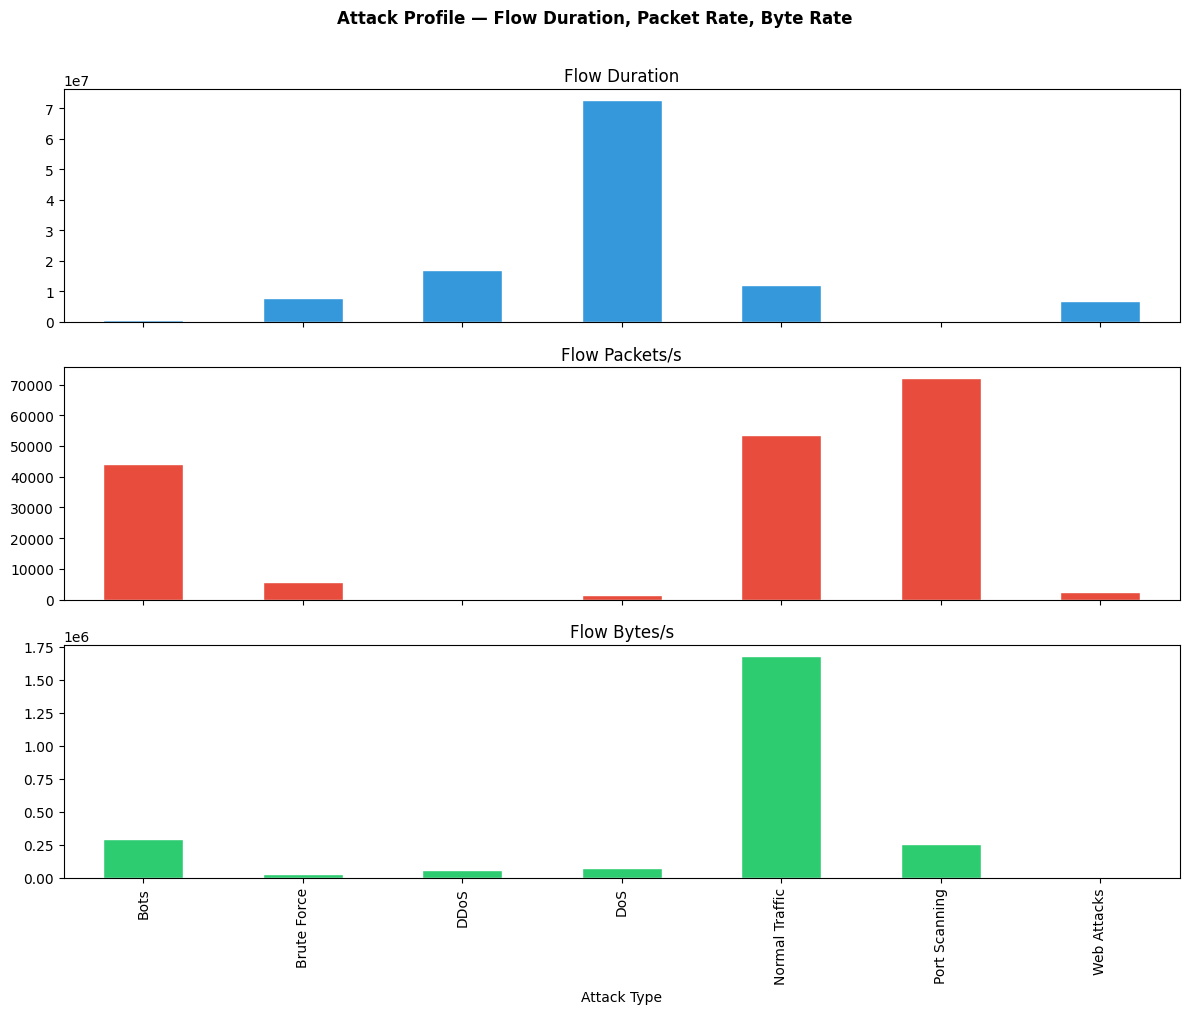

In [11]:
features = ['Flow Duration', 'Flow Packets/s', 'Flow Bytes/s']

df.groupby('Attack Type')[features].mean().plot(
    kind='bar',
    subplots=True,
    figsize=(12, 10),
    color=['#3498db', '#e74c3c', '#2ecc71'],
    edgecolor='white',
    legend=False
)

plt.suptitle('Attack Profile — Flow Duration, Packet Rate, Byte Rate',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_attack_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

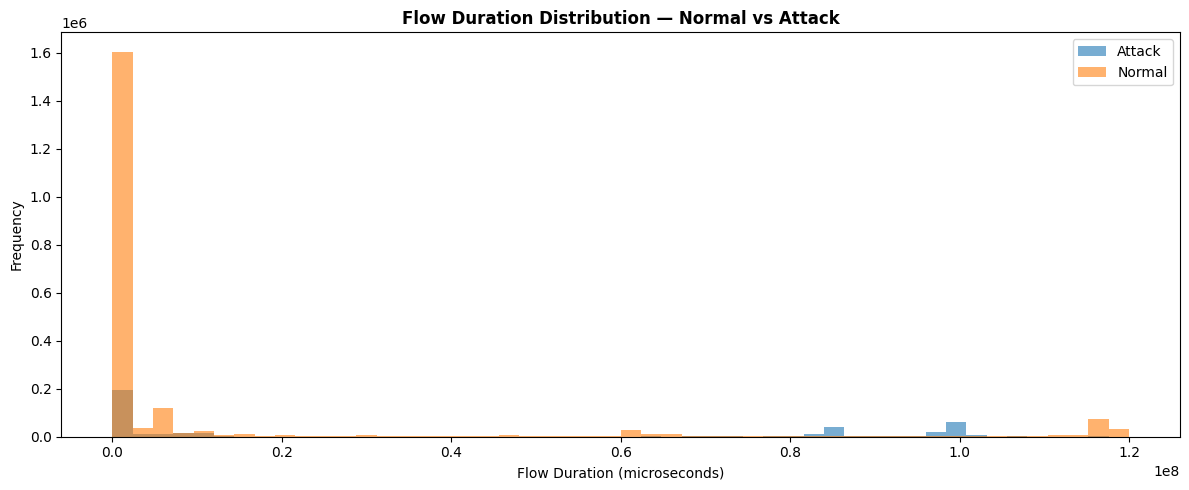

In [12]:
df.groupby('Traffic_Type')['Flow Duration'].plot(
    kind='hist',
    bins=50,
    alpha=0.6,
    figsize=(12, 5),
    legend=True
)

plt.title('Flow Duration Distribution — Normal vs Attack', fontweight='bold')
plt.xlabel('Flow Duration (microseconds)')
plt.tight_layout()
plt.savefig('03_flow_duration_hist.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
df.drop(columns=['Attack Type', 'Traffic_Type']).corr().round(2)

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min
Destination Port,1.000,-0.170,-0.000,0.010,0.090,-0.050,0.140,0.120,-0.210,-0.260,...,-0.130,0.210,-0.000,0.000,-0.040,-0.060,-0.030,-0.130,-0.120,-0.130
Flow Duration,-0.170,1.000,0.020,0.060,0.260,-0.120,0.130,0.220,0.490,-0.240,...,0.090,-0.030,0.020,-0.000,0.180,0.290,0.120,0.760,0.780,0.730
Total Fwd Packets,-0.000,0.020,1.000,0.380,0.010,-0.000,-0.000,0.000,0.020,-0.010,...,0.000,-0.000,0.890,-0.000,0.040,0.030,0.040,0.000,0.000,0.000
Total Length of Fwd Packets,0.010,0.060,0.380,1.000,0.200,-0.000,0.190,0.170,0.020,-0.030,...,0.030,0.010,0.420,-0.000,0.100,0.130,0.070,0.020,0.030,0.020
Fwd Packet Length Max,0.090,0.260,0.010,0.200,1.000,-0.000,0.890,0.970,0.080,-0.140,...,0.160,0.020,0.010,0.000,0.120,0.140,0.100,0.170,0.190,0.150
Fwd Packet Length Min,-0.050,-0.120,-0.000,-0.000,-0.000,1.000,0.240,-0.080,-0.130,0.300,...,-0.150,-0.070,-0.000,-0.000,-0.040,-0.050,-0.030,-0.080,-0.080,-0.070
Fwd Packet Length Mean,0.140,0.130,-0.000,0.190,0.890,0.240,1.000,0.900,-0.000,-0.040,...,0.050,-0.010,0.000,0.000,0.090,0.090,0.080,0.120,0.140,0.100
Fwd Packet Length Std,0.120,0.220,0.000,0.170,0.970,-0.080,0.900,1.000,0.080,-0.150,...,0.130,0.010,0.000,0.000,0.100,0.110,0.090,0.170,0.190,0.150
Bwd Packet Length Max,-0.210,0.490,0.020,0.020,0.080,-0.130,-0.000,0.080,1.000,-0.240,...,0.110,-0.060,0.020,0.000,0.070,0.070,0.070,0.570,0.570,0.550
Bwd Packet Length Min,-0.260,-0.240,-0.010,-0.030,-0.140,0.300,-0.040,-0.150,-0.240,1.000,...,-0.290,-0.140,-0.000,0.000,-0.070,-0.090,-0.060,-0.170,-0.180,-0.170


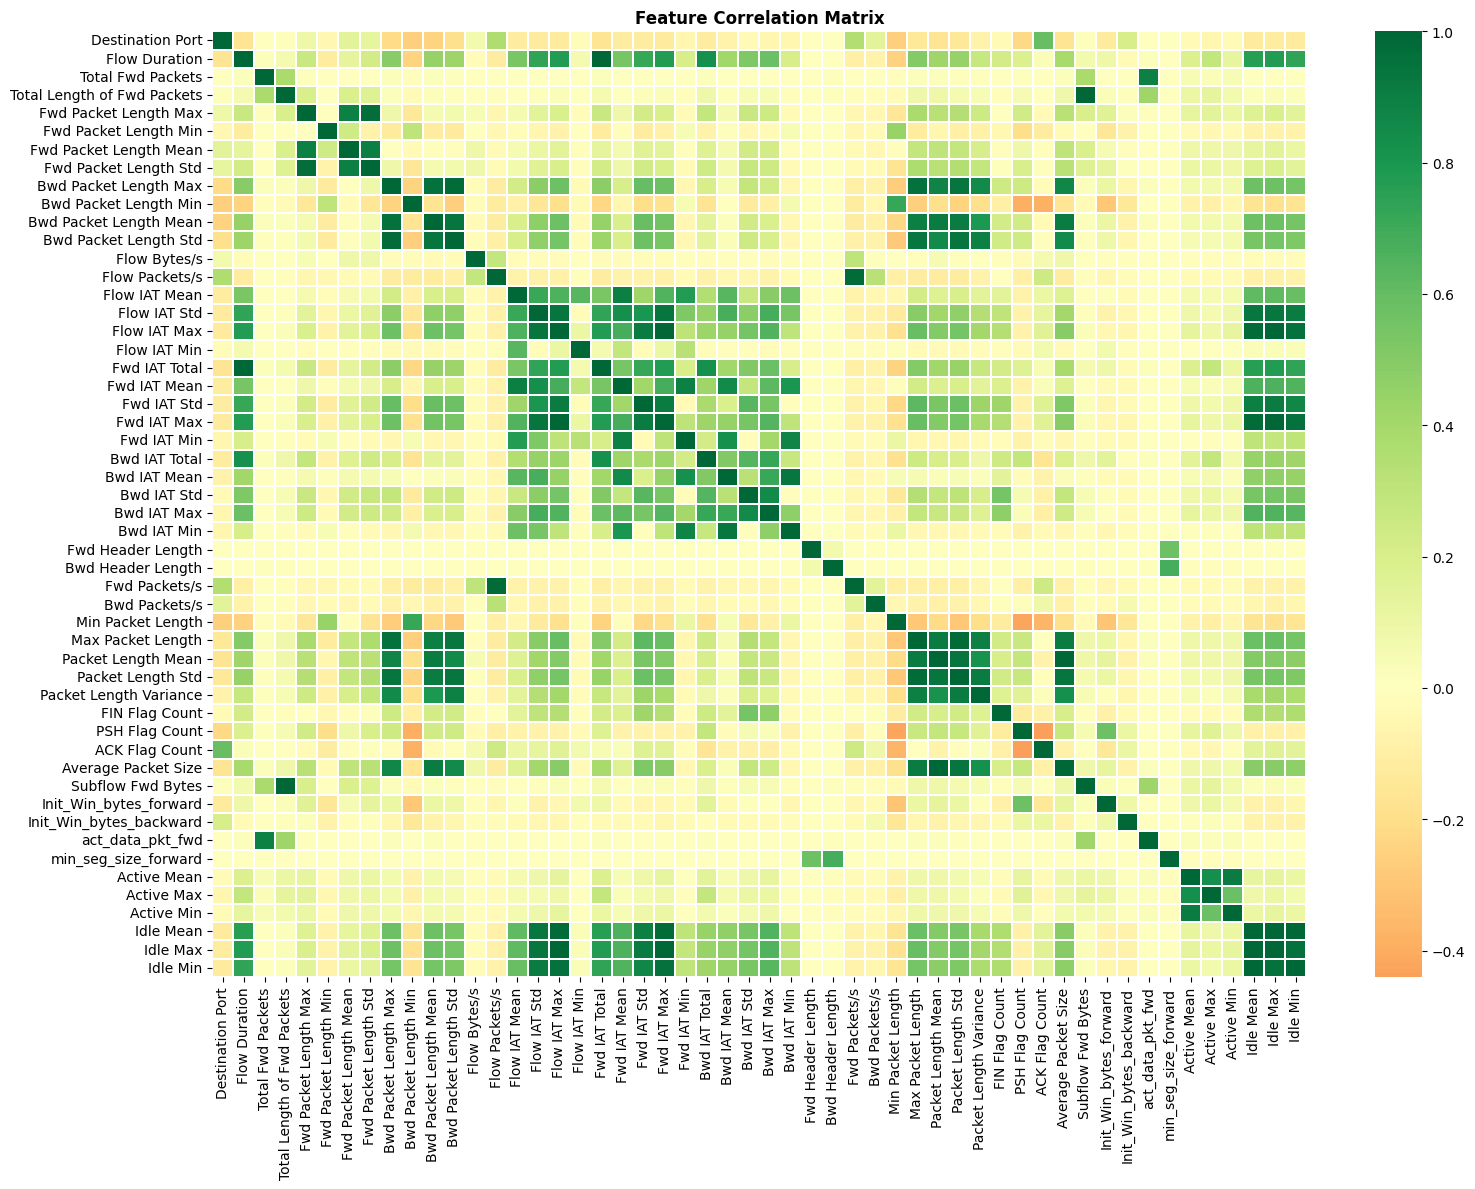

In [14]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    df.drop(columns=['Attack Type', 'Traffic_Type']).corr().round(2),
    cmap='RdYlGn',
    center=0,
    linewidths=0.3,
    annot=False
)

plt.title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

<Axes: >

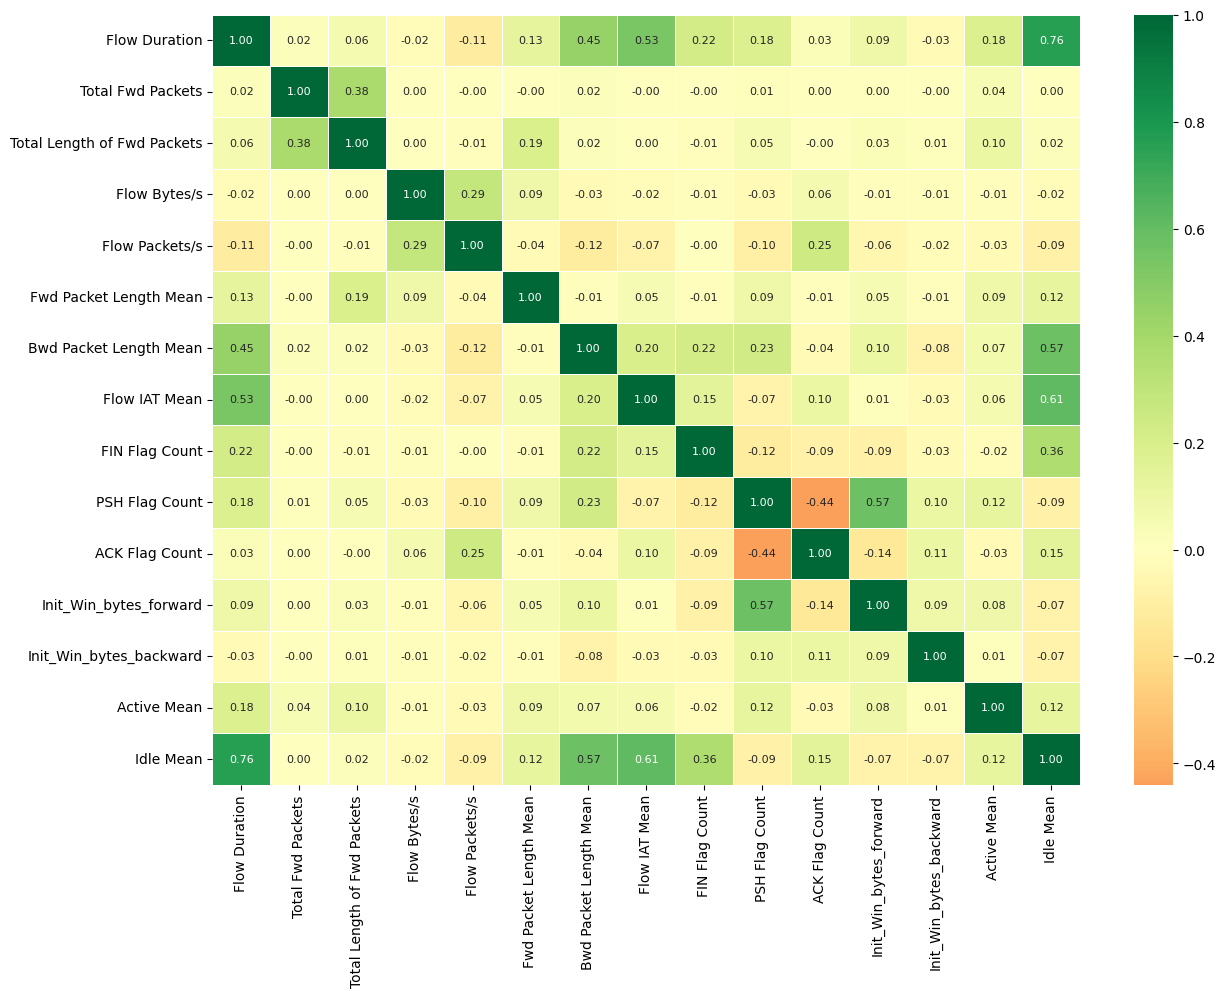

In [15]:
selected = [
    'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packet Length Mean',
    'Bwd Packet Length Mean', 'Flow IAT Mean', 'FIN Flag Count',
    'PSH Flag Count', 'ACK Flag Count', 'Init_Win_bytes_forward',
    'Init_Win_bytes_backward', 'Active Mean', 'Idle Mean'
]

plt.figure(figsize=(14, 10))

sns.heatmap(
    df[selected].corr().round(2),
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8}
)

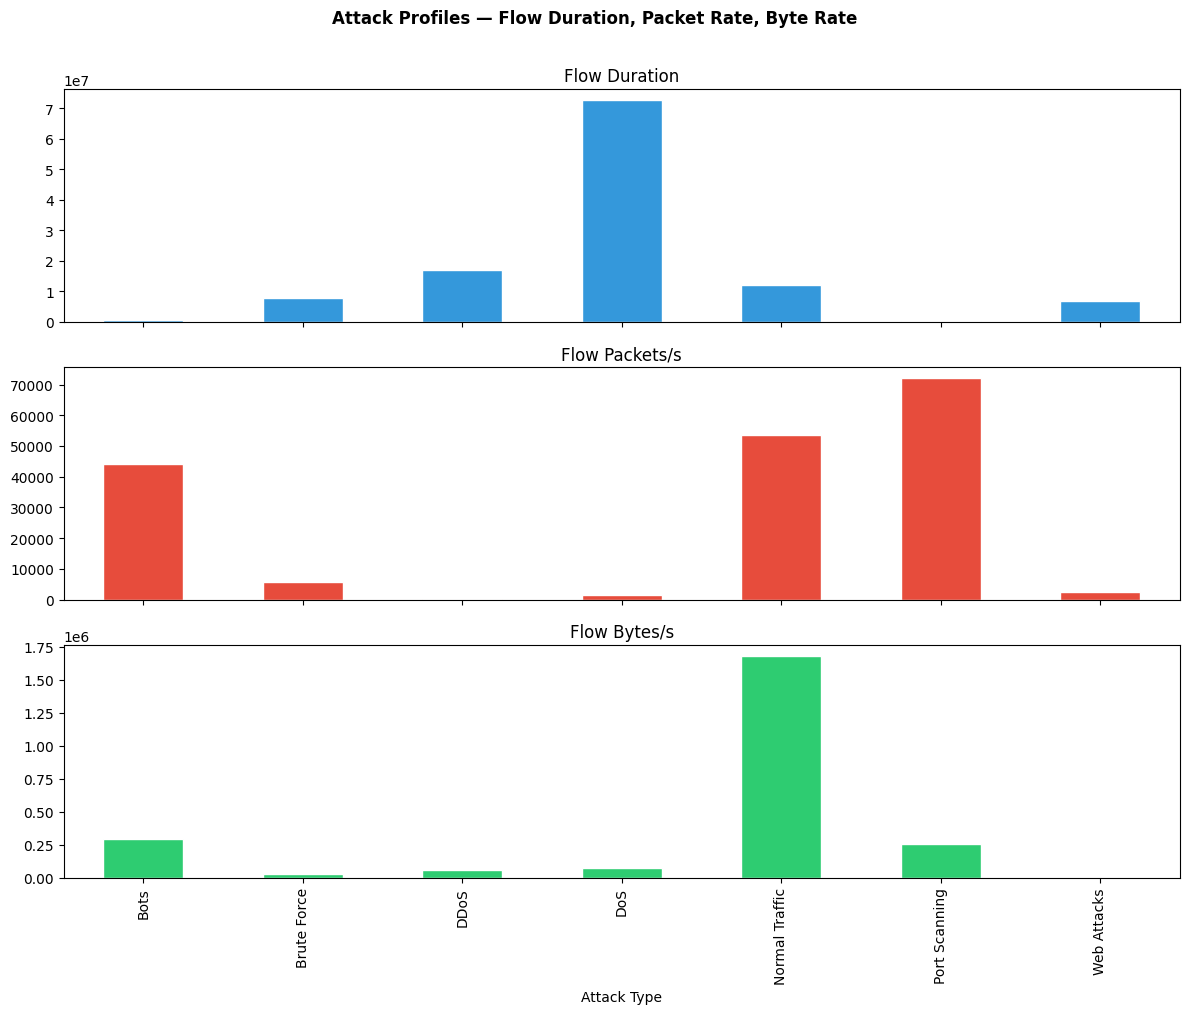

In [6]:
features = ['Flow Duration', 'Flow Packets/s', 'Flow Bytes/s']

df.groupby('Attack Type')[features].mean().plot(
    kind='bar',
    subplots=True,
    figsize=(12, 10),
    color=['#3498db', '#e74c3c', '#2ecc71'],
    edgecolor='white',
    legend=False
)

plt.suptitle('Attack Profiles — Flow Duration, Packet Rate, Byte Rate',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_attack_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

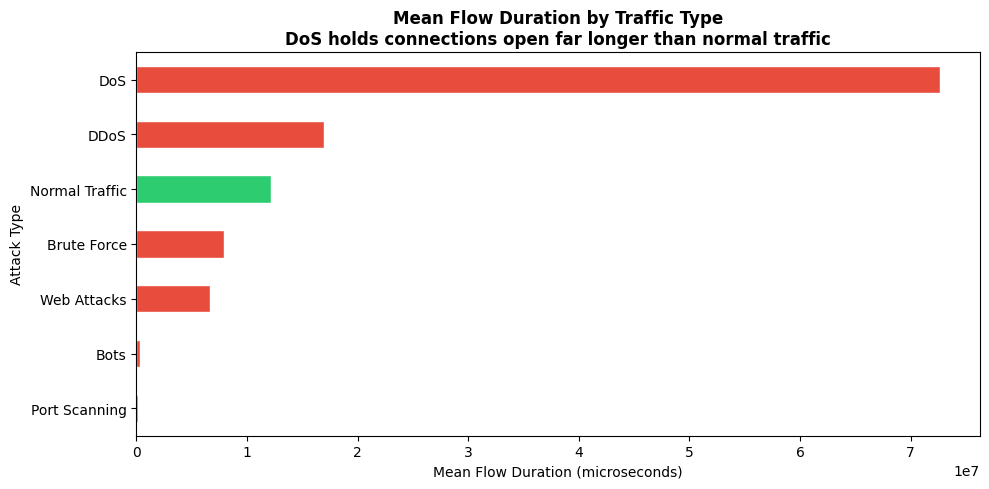

In [7]:
df.groupby('Attack Type')['Flow Duration'].mean().sort_values().plot(
    kind='barh',
    color=['#2ecc71' if 'Normal' in l else '#e74c3c'
           for l in df.groupby('Attack Type')['Flow Duration'].mean().sort_values().index],
    edgecolor='white',
    figsize=(10, 5)
)

plt.title('Mean Flow Duration by Traffic Type\nDoS holds connections open far longer than normal traffic',
          fontweight='bold')
plt.xlabel('Mean Flow Duration (microseconds)')
plt.tight_layout()
plt.savefig('02_flow_duration.png', dpi=150, bbox_inches='tight')
plt.show()

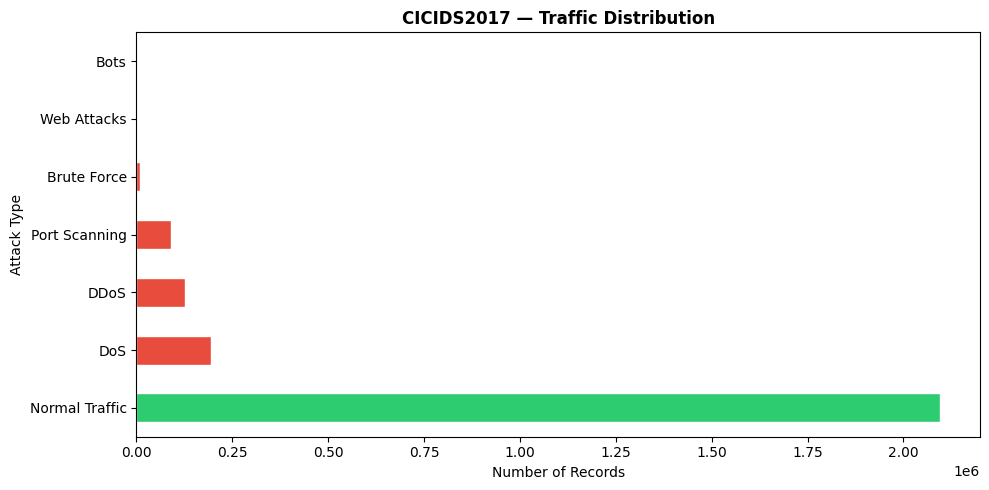

In [5]:
import matplotlib.pyplot as plt

label_counts = df['Attack Type'].value_counts()

label_counts.plot(kind='barh',
                  color=['#2ecc71' if 'Normal' in l else '#e74c3c' for l in label_counts.index],
                  edgecolor='white',
                  figsize=(10, 5))

plt.title('CICIDS2017 — Traffic Distribution', fontweight='bold')
plt.xlabel('Number of Records')
plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
df.groupby('Attack Type')['Destination Port'].agg(
    lambda x: x.value_counts().index[0]
).reset_index(name='Most Common Port')

,Attack Type,Most Common Port
0,Bots,8080
1,Brute Force,21
2,DDoS,80
3,DoS,80
4,Normal Traffic,53
5,Port Scanning,80
6,Web Attacks,80
